# Craving Prediction Model Sweep (Final Refined v4 - Hierarchical)

- **Models**: LR, RF, MLP, XGB
- **Modality**: ALL, ECG, PPG, EDA, PTT
- **Interpretability**: SHAP Beeswarm & Bar plots (Saved by Class/Modality)
- **Metrics**: Comprehensive score saving (Results separated by subfolders)
- **Organization**: Hierarchical directory structure (results/nc_class/modality/...)

In [1]:
import os
import sys
sys.path.append(os.path.abspath(".."))
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
import shap
import warnings
import re
from tqdm.notebook import tqdm

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score, 
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, precision_recall_curve, 
    average_precision_score, brier_score_loss, matthews_corrcoef, log_loss,
    precision_recall_fscore_support
)
from sklearn.model_selection import StratifiedGroupKFold, LeaveOneGroupOut
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier, DMatrix
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')

from src.ml.experiment_utils import seed_everything

SEED = 42
seed_everything(SEED)

# Project Paths
# notebook is assumed to be in repo root or under notebooks/
NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR if (NB_DIR / "src").exists() else NB_DIR.parent
DATA_DIR = REPO_ROOT / 'data'
Q_CSV = DATA_DIR / 'alcohol_Qscores.csv'
RUNS_DIR = REPO_ROOT / 'runs' / '08_final_report_v2'
RUNS_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_ROOT = RUNS_DIR / 'results'
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

def get_save_paths(nc, modality):
    base = EXPORT_ROOT / f"{nc}class" / modality
    paths = {
        'base': base,
        'plots': base / 'plots',
        'shap': base / 'shap',
        'csvs': base / 'csvs'
    }
    for p in paths.values(): p.mkdir(parents=True, exist_ok=True)
    return paths

import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

# Performance Plot Aesthetics (Large Fonts)
plt.rcParams.update({'font.size': 14, 'axes.labelsize': 16, 'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 12})


## 머신러닝

In [2]:
from src.ml.experiment_utils import (
    SAMPLING_RATE_ERROR, MISSING_PPG, MISSING_GSR,
    get_feature_cols_by_modality, load_and_label,
    compute_comprehensive_metrics, unwrap_shap, get_xgb_shap,
)

# ============================================================
#  Plotting (Binary)
# ============================================================
def _plot_curves_binary(ax_roc, ax_pr, ax_cal, y_true, proba, label):
    if isinstance(proba, list):
        proba = np.array(proba)

    p1 = proba[:, 1]

    # ROC
    if ax_roc is not None:
        fpr, tpr, _ = roc_curve(y_true, p1)
        auc = roc_auc_score(y_true, p1)
        ax_roc.plot(fpr, tpr, lw=2, label=f"{label} (AUROC={auc:.2f})")

    # PR
    if ax_pr is not None:
        prec, rec, _ = precision_recall_curve(y_true, p1)
        ap = average_precision_score(y_true, p1)
        ax_pr.plot(rec, prec, lw=2, label=f"{label} (AUPRC={ap:.2f})")

    # Calibration
    if ax_cal is not None:
        f_pos, m_pred = calibration_curve(y_true, p1, n_bins=10)
        brier = brier_score_loss(y_true, p1)
        ax_cal.plot(m_pred, f_pos, marker="o", lw=1.5, label=f"{label} (Brier score loss={brier:.3f})")

# ============================================================
#  Plotting (Multiclass)
# ============================================================
def _plot_curves_multiclass(ax_roc, ax_pr, ax_cal, y_true, proba, classes, label, show_classwise=False):
    if isinstance(proba, list):
        proba = np.array(proba)

    Y = label_binarize(y_true, classes=classes)
    n_classes = len(classes)

    # ---------------------------
    # OVR 세부 선 (옵션)
    # ---------------------------
    if show_classwise:
        for ci in range(n_classes):
            if np.unique(Y[:, ci]).size < 2:
                continue
            # ROC
            if ax_roc is not None:
                fpr, tpr, _ = roc_curve(Y[:, ci], proba[:, ci])
                ax_roc.plot(fpr, tpr, lw=1, alpha=0.12, color='gray')

            # PR
            if ax_pr is not None:
                prec, rec, _ = precision_recall_curve(Y[:, ci], proba[:, ci])
                ax_pr.plot(rec, prec, lw=1, alpha=0.12, color='gray')

    # ---------------------------
    # Macro ROC
    #---------------------------
    if ax_roc is not None:
        all_fpr = np.linspace(0, 1, 200)
        mean_tpr = np.zeros_like(all_fpr)

        for ci in range(n_classes):
            if np.unique(Y[:, ci]).size < 2:
                continue
            fpr, tpr, _ = roc_curve(Y[:, ci], proba[:, ci])
            mean_tpr += np.interp(all_fpr, fpr, tpr)

        mean_tpr /= n_classes
        mauc = roc_auc_score(Y, proba, average='macro', multi_class='ovr')

        ax_roc.plot(all_fpr, mean_tpr, lw=2, label=f"{label} (AUROC={mauc:.2f})")

    # ---------------------------
    # Macro PR
    #---------------------------
    if ax_pr is not None:
        all_rec = np.linspace(0, 1, 200)
        mean_prec = np.zeros_like(all_rec)

        for ci in range(n_classes):
            if np.unique(Y[:, ci]).size < 2:
                continue
            prec, rec, _ = precision_recall_curve(Y[:, ci], proba[:, ci])
            mean_prec += np.interp(all_rec, rec[::-1], prec[::-1])

        mean_prec /= n_classes
        mapc = average_precision_score(Y, proba, average='macro')

        ax_pr.plot(all_rec, mean_prec, lw=2, label=f"{label} (AUPRC={mapc:.2f})")

    # Calibration (multiclass는 표시 불가 - Brier score만 표시)
    if ax_cal is not None:
        brier = np.mean(np.sum((proba - Y)**2, axis=1))
        ax_cal.plot([], [], label=f"{label} (Brier score loss={brier:.3f})")

# ============================================================
#  Save Figure
# ============================================================
def save_compare_figure(curves_dict, classes, out_path_base, title_prefix=""):
    # --- 핵심 패치: 모든 y_true 를 numpy array로 변환 ---
    new_dict = {}
    for k, (yt, pb) in curves_dict.items():
        new_dict[k] = (np.asarray(yt), np.asarray(pb))
    curves_dict = new_dict

    # baseline 준비
    yt_any = list(curves_dict.values())[0][0]
    pos_rate = (yt_any == 1).mean() if len(classes) == 2 else label_binarize(yt_any, classes=classes).mean(axis=0).mean()

    # 1. Combined Figure (Legacy)
    plt.figure(figsize=(15, 5), dpi=600)
    ax1, ax2, ax3 = plt.subplot(1, 3, 1), plt.subplot(1, 3, 2), plt.subplot(1, 3, 3)
    ax1.plot([0, 1], [0, 1], "--", color='gray', label='Random Classifier')
    ax2.hlines(pos_rate, 0, 1, colors='gray', linestyles='--', label='Random Classifier')
    ax3.plot([0, 1], [0, 1], "--", color='gray', label='Perfectly Calibrated')

    for m, (yt, pb) in curves_dict.items():
        if len(classes) == 2:
            _plot_curves_binary(ax1, ax2, ax3, yt, pb, m)
        else:
            _plot_curves_multiclass(ax1, ax2, ax3, yt, pb, classes, m)

    # ax1.set_title("ROC Curve")
    ax1.set_xlabel("False Positive Rate", fontsize=16); ax1.set_ylabel("True Positive Rate", fontsize=16); ax1.legend(fontsize=14)
    # ax2.set_title("Precision-Recall Curve"); 
    ax2.set_xlabel("Recall", fontsize=16); ax2.set_ylabel("Precision", fontsize=16); ax2.legend(fontsize=14)
    # ax3.set_title("Calibration Curve"); 
    ax3.set_xlabel("Mean predicted value", fontsize=16); ax3.set_ylabel("Fraction of positives", fontsize=16); ax3.legend(fontsize=14)

    # if title_prefix:
        # plt.suptitle(title_prefix)

    plt.tight_layout()
    plt.savefig(out_path_base / 'curves_comparison.png')
    plt.close()

    # 2. Individual Figures
    # ROC
    plt.figure(figsize=(5, 5), dpi=600)
    ax = plt.gca()
    ax.plot([0, 1], [0, 1], "--", color='gray', label='Random Classifier')
    for m, (yt, pb) in curves_dict.items():
        if len(classes) == 2: _plot_curves_binary(ax, None, None, yt, pb, m)
        else: _plot_curves_multiclass(ax, None, None, yt, pb, classes, m)
    # ax.set_title(f"ROC Curve\n{title_prefix}"); 
    ax.set_xlabel("False Positive Rate", fontsize=16); ax.set_ylabel("True Positive Rate", fontsize=16); ax.legend(fontsize=14)
    plt.tight_layout(); plt.savefig(out_path_base / 'roc_curve.png', bbox_inches="tight"); plt.close()

    # PR
    plt.figure(figsize=(5, 5), dpi=600)
    ax = plt.gca()
    ax.hlines(pos_rate, 0, 1, colors='gray', linestyles='--', label='Random Classifier')
    for m, (yt, pb) in curves_dict.items():
        if len(classes) == 2: _plot_curves_binary(None, ax, None, yt, pb, m)
        else: _plot_curves_multiclass(None, ax, None, yt, pb, classes, m)
    # ax.set_title(f"Precision-Recall Curve\n{title_prefix}"); 
    ax.set_xlabel("Recall", fontsize=18); ax.set_ylabel("Precision", fontsize=18); ax.legend(fontsize=12)
    plt.tight_layout(); plt.savefig(out_path_base / 'pr_curve.png', bbox_inches="tight"); plt.close()

    # Calibration
    plt.figure(figsize=(5, 5), dpi=600)
    ax = plt.gca()
    ax.plot([0, 1], [0, 1], "--", color='gray', label='Perfectly Calibrated')
    for m, (yt, pb) in curves_dict.items():
        if len(classes) == 2: _plot_curves_binary(None, None, ax, yt, pb, m)
        else: _plot_curves_multiclass(None, None, ax, yt, pb, classes, m)
    # ax.set_title(f"Calibration Curve\n{title_prefix}"); 
    ax.set_xlabel("Mean predicted value", fontsize=18); ax.set_ylabel("Fraction of positives", fontsize=18); ax.legend(fontsize=12)
    plt.tight_layout(); plt.savefig(out_path_base / 'calibration_curve.png'); plt.close()

# ============================================================
#  Confusion matrix refined
# ============================================================
def save_cm_refined(y_true, y_pred, classes, path, title, display_labels=None):
    conf_mat = confusion_matrix(y_true, y_pred, labels=classes)
    cm_norm = conf_mat / np.maximum(conf_mat.sum(axis=1, keepdims=True), 1e-12) * 100

    tick_labels = display_labels if display_labels is not None else classes

    plt.figure(figsize=(5, 5), dpi=600)
    annot = np.empty_like(conf_mat).astype(str)

    for i in range(conf_mat.shape[0]):
        row_vals = cm_norm[i].copy()
        rounded = np.round(row_vals, 1)

        # 반올림 오차 보정: 마지막 칸에 차이 반영
        diff = np.round(100.0 - rounded.sum(), 1)
        rounded[-1] = np.round(rounded[-1] + diff, 1)

        for j in range(conf_mat.shape[1]):
            annot[i, j] = f"{rounded[j]:.1f}%"

    ax = sns.heatmap(
        data=cm_norm,
        annot=annot,
        fmt="",
        cmap="Blues",
        xticklabels=tick_labels,
        yticklabels=tick_labels,
        annot_kws={"size": 22, "weight": "bold"},
        cbar=False
    )

    plt.xlabel("Predicted", fontsize=18)
    plt.ylabel("True", fontsize=18)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.close()
    
def run_full_experiment(df, feats, model_name, paths, nc_name, mod_name):
           
    X, y, groups = df[feats], df['y'], df['group_id']; classes_list = sorted(np.unique(y)); nc = len(classes_list); 
    
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

    yt_all, yp_all, pb_all, s_all = [], [], [], []
    for f, (tr, te) in enumerate(cv.split(X, y, groups)):
        Xtr, Xte, ytr, yte = X.iloc[tr], X.iloc[te], y.iloc[tr], y.iloc[te]
        # 모델 설정 부분
        if model_name == 'LR':
            clf = LogisticRegression(solver='saga', penalty='l2', max_iter=8000, random_state=SEED, class_weight='balanced')

        elif model_name == 'MLP':
            # 2-layer FC layer (예: 64개 노드 -> 32개 노드)
            clf = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=2000, early_stopping=True, n_iter_no_change=30, random_state=SEED)

        elif model_name == 'RF':
            clf = RandomForestClassifier(n_estimators=500, random_state=SEED, class_weight='balanced_subsample', n_jobs=-1)

        elif model_name == 'XGB':
            clf = XGBClassifier(n_estimators=100, random_state=SEED, n_jobs=-1, objective='multi:softprob' if nc > 2 else 'binary:logistic')

        elif model_name == 'SVM':
            # Calibration Curve를 그리려면 probability=True 설정이 반드시 필요합니다.
            clf = SVC(kernel='rbf', probability=True, random_state=SEED, class_weight='balanced')

        elif model_name == 'KNN':
            # KNN은 별도의 random_state가 없으며, n_neighbors는 데이터 특성에 따라 조절이 필요합니다.
            clf = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
        pe = Pipeline([('scaler', StandardScaler()), ('clf', clf)]); pe.fit(Xtr, ytr)
        yt_all.extend(yte); yp_all.extend(pe.predict(Xte)); pb_all.extend(pe.predict_proba(Xte))
        if model_name in ['LR', 'XGB', 'RF']:
            try:
                Xtes = pe.named_steps['scaler'].transform(Xte)
                if model_name == 'XGB': sl = get_xgb_shap(pe, Xtes)
                elif model_name == 'RF':
                    sl_raw = shap.TreeExplainer(pe.named_steps['clf']).shap_values(Xtes, approximate=True, check_additivity=False)
                    sl = unwrap_shap(sl_raw)
                else: 
                    bX = pe.named_steps['scaler'].transform(Xtr.sample(min(100, len(Xtr)), random_state=SEED))
                    sl = unwrap_shap(shap.LinearExplainer(pe.named_steps['clf'], bX).shap_values(Xtes))
                s_all.append({'X': Xtes, 'S': sl})
            except Exception as e: print(f"  [SHAP Error Fold {f+1}] {e}")
    
    pb_all = np.array(pb_all); 
    
    display_names = ['zero', 'low', 'high'] if nc==3 else ['zero', 'non-zero']

    save_cm_refined(yt_all, yp_all, classes_list, 
                    paths['plots'] / f'cm_{model_name}.png', 
                    f"{model_name} | {nc_name} | {mod_name}",
                    display_labels=display_names)
                    
    if s_all:
        Xc = np.concatenate([d['X'] for d in s_all], axis=0)
        nsc = len(s_all[0]['S'])

        # --------------------------------------------------
        # Consolidated SHAP importance CSV (all folds pooled)
        # --------------------------------------------------
        if nc > 2 and nsc > 1:
            list_Sc = [np.concatenate([d['S'][ci] for d in s_all], axis=0) for ci in range(nsc)]
            mabs_all = np.mean([np.mean(np.abs(s), axis=0) for s in list_Sc], axis=0)
        else:
            Sc_all = np.concatenate([d['S'][0] for d in s_all], axis=0)
            mabs_all = np.mean(np.abs(Sc_all), axis=0)

        pd.DataFrame({
            'feature': feats,
            'mean_abs_shap': mabs_all
        }).sort_values(
            'mean_abs_shap',
            ascending=False
        ).to_csv(
            paths['csvs'] / f'shap_importance_{model_name}_all_classes.csv',
            index=False
        )

        # Multiclass Consolidated Plot (Bar)
        if nc > 2 and nsc > 1:
            list_Sc = [np.concatenate([d['S'][ci] for d in s_all], axis=0) for ci in range(nsc)]

            desired_classes = [0, 1, 2]
            name_map = {
                0: "zero",
                1: "low",
                2: "high",
            }

            class_to_idx = {c: i for i, c in enumerate(classes_list)}
            order_idx = [class_to_idx[c] for c in desired_classes]

            list_Sc_ordered = [list_Sc[i] for i in order_idx]
            class_names_ordered = [name_map[c] for c in desired_classes]

            plt.figure(figsize=(10, 8))
            shap.summary_plot(
                list_Sc_ordered,
                Xc,
                feature_names=feats,
                show=False,
                max_display=20,
                plot_type="bar",
                class_names=class_names_ordered,
                class_inds="original"
            )
            plt.tight_layout()
            plt.savefig(paths['shap'] / f'shap_bar_{model_name}_all_classes.png', dpi=600)
            plt.close()
        
        # Per-class plots (Dots always, Bar/CSV only if not consolidated)
        for ci in range(nsc):
            Sc = np.concatenate([d['S'][ci] for d in s_all], axis=0)
            target = classes_list[ci] if nsc > 1 else (classes_list[1] if nc == 2 else classes_list[0])
            mabs = np.mean(np.abs(Sc), axis=0)
            
            if not (nc > 2): # For binary, still save the main class bar/csv
                pd.DataFrame({'feature': feats, 'mean_abs_shap': mabs}).sort_values('mean_abs_shap', ascending=False).to_csv(paths['csvs'] / f'shap_importance_{model_name}_class{target}.csv', index=False)
                plt.figure(figsize=(10, 8)); shap.summary_plot(Sc, Xc, feature_names=feats, show=False, max_display=20, plot_type="bar"); 
                # plt.title(f"SHAP Importance: {model_name} | {mod_name} | Class {target}"); 
                plt.tight_layout(); plt.savefig(paths['shap'] / f'shap_bar_{model_name}_class{target}.png', dpi=600); plt.close()

                # # Consolidated CSV 
                # mabs_all = np.mean([np.mean(np.abs(s), axis=0) for s in list_Sc], axis=0) 
                # pd.DataFrame({'feature': feats, 'mean_abs_shap': mabs_all}).sort_values('mean_abs_shap', ascending=False).to_csv(paths['csvs'] / f'shap_importance_{model_name}_all_classes.csv', index=False)
            
            # Beeswarm is always useful per class
            plt.figure(figsize=(10, 8)); shap.summary_plot(Sc, Xc, feature_names=feats, show=False, max_display=20, plot_type="dot"); 
            # plt.title(f"SHAP Beeswarm: {model_name} | {mod_name} | Class {target}"); 
            plt.tight_layout(); plt.savefig(paths['shap'] / f'shap_dot_{model_name}_class{target}.png', dpi=600); plt.close()
            plt.figure(figsize=(10, 8)); shap.summary_plot(Sc, Xc, feature_names=feats, show=False, max_display=20, plot_type="violin"); 
            # plt.title(f"SHAP Beeswarm: {model_name} | {mod_name} | Class {target}"); 
            plt.tight_layout(); plt.savefig(paths['shap'] / f'shap_violin_{model_name}_class{target}.png', dpi=600); plt.close()

    return compute_comprehensive_metrics(yt_all, yp_all, pb_all, classes_list), yt_all, pb_all
    

In [3]:
df, af = load_and_label('10s', REPO_ROOT, Q_CSV, n_classes=3, filter_abnormal=True, prefix="_05_70_3")

print("Overall label ratio:")
print(df["y"].value_counts(normalize=True).sort_index())
print(df["y"].value_counts().sort_index())

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)


X = df["PPG_HR"]
y = df["y"]
groups = df["group_id"]

for fold, (tr, te) in enumerate(cv.split(X, y, groups), start=1):
    print(f"\n[Fold {fold}]")
    print("train ratio")
    print(y.iloc[tr].value_counts(normalize=True).sort_index())
    print(y.iloc[tr].value_counts().sort_index())

    print("test ratio")
    print(y.iloc[te].value_counts(normalize=True).sort_index())
    print(y.iloc[te].value_counts().sort_index())

  [Filter] NULL applied to abnormal sessions (no row drop)
Skipping EDA_SCR_IPI_Mean: NaN ratio 50.25%
Skipping EDA_SCR_IPI_SD: NaN ratio 50.25%
Skipping ECG_HRV_DFA_alpha1: NaN ratio 54.49%
Skipping ECG_HRV_HFD: NaN ratio 99.34%
Skipping ECG_HRV_MFDFA_alpha1_Asymmetry: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Delta: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Fluctuation: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Increment: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Max: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Mean: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Peak: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Width: NaN ratio 54.49%
Skipping ECG_HRV_SampEn: NaN ratio 87.55%
Skipping ECG_HRV_Symbolic_EqualProb4_0V: Symbolic_EqualProb
Skipping ECG_HRV_Symbolic_EqualProb4_1V: Symbolic_EqualProb
Skipping ECG_HRV_Symbolic_EqualProb4_2LV: Symbolic_EqualProb
Skipping ECG_HRV_Symbolic_EqualProb4_2UV: Symbolic_EqualProb
Skipping ECG_HRV_TP: Constant value
Skipping


[Fold 1]
train ratio
y
0    0.347197
1    0.310880
2    0.341923
Name: proportion, dtype: float64
y
0    2304
1    2063
2    2269
Name: count, dtype: int64
test ratio
y
0    0.385986
1    0.323294
2    0.290719
Name: proportion, dtype: float64
y
0    628
1    526
2    473
Name: count, dtype: int64

[Fold 2]
train ratio
y
0    0.356270
1    0.322921
2    0.320809
Name: proportion, dtype: float64
y
0    2361
1    2140
2    2126
Name: count, dtype: int64
test ratio
y
0    0.349022
1    0.274450
2    0.376528
Name: proportion, dtype: float64
y
0    571
1    449
2    616
Name: count, dtype: int64

[Fold 3]
train ratio
y
0    0.360551
1    0.306620
2    0.332828
Name: proportion, dtype: float64
y
0    2380
1    2024
2    2197
Name: count, dtype: int64
test ratio
y
0    0.332130
1    0.339952
2    0.327918
Name: proportion, dtype: float64
y
0    552
1    565
2    545
Name: count, dtype: int64

[Fold 4]
train ratio
y
0    0.354809
1    0.312870
2    0.332320
Name: proportion, dtype: float64
y

In [4]:
all_results = []
for nc in [2, 3]:
    for dur in ['10s']:
        # compare='z_vs_lh': zero vs. non-zero craving -- paper's binary "Craving Detection" setting (Table III).
        # Full 152-feature set here (no selected_feature_csv) -- Table VII's 36-feature re-run is a
        # separate sweep further below, after the LMM+SHAP candidate-feature selection has been computed.
        db, af = load_and_label(dur, REPO_ROOT, Q_CSV, n_classes=nc, filter_abnormal=True, prefix="_05_70_3", compare='z_vs_lh')
        if db is None:
            continue

        # Modality ablation (Tables V/VI) is reported for the 3-class setting only.
        modalities = ['ALL', 'ECG', 'PPG', 'EDA', 'PTT'] if nc == 3 else ['ALL']
        for mod in modalities:
            seed_everything(SEED)
            mff = get_feature_cols_by_modality(af, mod)
            if not mff:
                continue

            print(f"\nSweep: {nc}-Class | {dur} | {mod} ({len(mff)} features)")

            print(mff)

            # ------------------------------------------------------
            # 🔥 모달리티별 abnormal session 제거 (가장 중요한 부분)
            # ------------------------------------------------------
            if mod != 'ALL':
                if mod == 'PPG':
                    bad = MISSING_PPG
                elif mod == 'EDA':
                    bad = MISSING_GSR
                elif mod == 'ECG':
                    bad = SAMPLING_RATE_ERROR
                elif mod == 'PTT':
                    bad = list(set(MISSING_PPG) | set(SAMPLING_RATE_ERROR))

                db_mod = db[~db['session_id'].isin(bad)].reset_index(drop=True)
            else:
                db_mod = db.copy()

            print(f" - Samples: {len(db_mod)}")
            # Preserve data for LMM analysis
            if nc == 3 and mod == 'ALL':
                df_3c = db_mod.copy()
                feats_3c = list(mff)

            # ------------------------------------------------------
            # 모델 학습
            # ------------------------------------------------------
            paths = get_save_paths(nc, mod)
            cur_curves = {}

            for m_name in ['KNN', 'SVM', 'LR', 'MLP', 'XGB', 'RF']:
                if mod in ['ECG', 'PPG', 'EDA', 'PTT'] and m_name in ['KNN', 'SVM', 'LR', 'MLP']: continue
                try:
                    m_res, yt, pb = run_full_experiment(
                        db_mod, mff, m_name, paths, f"{nc}class", mod
                    )
                    m_res.update({
                        'n_classes': nc,
                        'duration': dur,
                        'modality': mod,
                        'model': m_name,
                        'samples': len(db_mod),
                    })
                    all_results.append(m_res)
                    cur_curves[m_name] = (yt, pb)
                except Exception as e:
                    print(f"  [Error {m_name}] {e}")

            if cur_curves:
                save_compare_figure(
                    cur_curves,
                    np.unique(db_mod['y']),
                    paths['plots'],
                    f"Models Comparisons | {nc}c | {dur} | {mod}"
                )
pd.DataFrame(all_results).to_csv(EXPORT_ROOT / 'results_metrics_all.csv', index=False)
print("\n✅ Tables III-VI complete (full-feature sweep + 3-class modality ablation). "
      "Results in 'runs/08_final_report_v2/results'. Table VII (36-feature re-run) runs "
      "later, after the LMM+SHAP candidate-feature selection below.")

  [Filter] NULL applied to abnormal sessions (no row drop)
Skipping EDA_SCR_IPI_Mean: NaN ratio 50.25%
Skipping EDA_SCR_IPI_SD: NaN ratio 50.25%
Skipping ECG_HRV_DFA_alpha1: NaN ratio 54.49%
Skipping ECG_HRV_HFD: NaN ratio 99.34%
Skipping ECG_HRV_MFDFA_alpha1_Asymmetry: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Delta: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Fluctuation: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Increment: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Max: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Mean: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Peak: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Width: NaN ratio 54.49%
Skipping ECG_HRV_SampEn: NaN ratio 87.55%
Skipping ECG_HRV_Symbolic_EqualProb4_0V: Symbolic_EqualProb
Skipping ECG_HRV_Symbolic_EqualProb4_1V: Symbolic_EqualProb
Skipping ECG_HRV_Symbolic_EqualProb4_2LV: Symbolic_EqualProb
Skipping ECG_HRV_Symbolic_EqualProb4_2UV: Symbolic_EqualProb
Skipping ECG_HRV_TP: Constant value
Skipping

  [Filter] NULL applied to abnormal sessions (no row drop)
Skipping EDA_SCR_IPI_Mean: NaN ratio 50.25%
Skipping EDA_SCR_IPI_SD: NaN ratio 50.25%
Skipping ECG_HRV_DFA_alpha1: NaN ratio 54.49%
Skipping ECG_HRV_HFD: NaN ratio 99.34%
Skipping ECG_HRV_MFDFA_alpha1_Asymmetry: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Delta: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Fluctuation: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Increment: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Max: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Mean: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Peak: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Width: NaN ratio 54.49%
Skipping ECG_HRV_SampEn: NaN ratio 87.55%
Skipping ECG_HRV_Symbolic_EqualProb4_0V: Symbolic_EqualProb
Skipping ECG_HRV_Symbolic_EqualProb4_1V: Symbolic_EqualProb
Skipping ECG_HRV_Symbolic_EqualProb4_2LV: Symbolic_EqualProb
Skipping ECG_HRV_Symbolic_EqualProb4_2UV: Symbolic_EqualProb
Skipping ECG_HRV_TP: Constant value
Skipping


Sweep: 3-Class | 10s | ECG (55 features)
['ECG_HR', 'ECG_HRV_AI', 'ECG_HRV_ApEn', 'ECG_HRV_C1a', 'ECG_HRV_C1d', 'ECG_HRV_C2a', 'ECG_HRV_C2d', 'ECG_HRV_CD', 'ECG_HRV_CSI', 'ECG_HRV_CSI_Modified', 'ECG_HRV_CVI', 'ECG_HRV_CVNN', 'ECG_HRV_CVSD', 'ECG_HRV_Ca', 'ECG_HRV_Cd', 'ECG_HRV_FuzzyEn', 'ECG_HRV_GI', 'ECG_HRV_HTI', 'ECG_HRV_IALS', 'ECG_HRV_IQRNN', 'ECG_HRV_KFD', 'ECG_HRV_LZC', 'ECG_HRV_MCVNN', 'ECG_HRV_MadNN', 'ECG_HRV_MaxNN', 'ECG_HRV_MeanNN', 'ECG_HRV_MedianNN', 'ECG_HRV_MinNN', 'ECG_HRV_PAS', 'ECG_HRV_PI', 'ECG_HRV_PIP', 'ECG_HRV_PSS', 'ECG_HRV_Prc20NN', 'ECG_HRV_Prc80NN', 'ECG_HRV_RMSSD', 'ECG_HRV_S', 'ECG_HRV_SD1', 'ECG_HRV_SD1SD2', 'ECG_HRV_SD1a', 'ECG_HRV_SD1d', 'ECG_HRV_SD2', 'ECG_HRV_SD2a', 'ECG_HRV_SD2d', 'ECG_HRV_SDNN', 'ECG_HRV_SDNNa', 'ECG_HRV_SDNNd', 'ECG_HRV_SDRMSSD', 'ECG_HRV_SDSD', 'ECG_HRV_SI', 'ECG_HRV_ShanEn', 'ECG_HRV_TINN', 'ECG_HRV_pNN20', 'ECG_HRV_pNN50', 'ECG_RR', 'ECG_SI']
 - Samples: 8263



Sweep: 3-Class | 10s | PPG (55 features)
['PPG_HR', 'PPG_HRV_AI', 'PPG_HRV_ApEn', 'PPG_HRV_C1a', 'PPG_HRV_C1d', 'PPG_HRV_C2a', 'PPG_HRV_C2d', 'PPG_HRV_CD', 'PPG_HRV_CSI', 'PPG_HRV_CSI_Modified', 'PPG_HRV_CVI', 'PPG_HRV_CVNN', 'PPG_HRV_CVSD', 'PPG_HRV_Ca', 'PPG_HRV_Cd', 'PPG_HRV_FuzzyEn', 'PPG_HRV_GI', 'PPG_HRV_HTI', 'PPG_HRV_IALS', 'PPG_HRV_IQRNN', 'PPG_HRV_KFD', 'PPG_HRV_LZC', 'PPG_HRV_MCVNN', 'PPG_HRV_MadNN', 'PPG_HRV_MaxNN', 'PPG_HRV_MeanNN', 'PPG_HRV_MedianNN', 'PPG_HRV_MinNN', 'PPG_HRV_PAS', 'PPG_HRV_PI', 'PPG_HRV_PIP', 'PPG_HRV_PSS', 'PPG_HRV_Prc20NN', 'PPG_HRV_Prc80NN', 'PPG_HRV_RMSSD', 'PPG_HRV_S', 'PPG_HRV_SD1', 'PPG_HRV_SD1SD2', 'PPG_HRV_SD1a', 'PPG_HRV_SD1d', 'PPG_HRV_SD2', 'PPG_HRV_SD2a', 'PPG_HRV_SD2d', 'PPG_HRV_SDNN', 'PPG_HRV_SDNNa', 'PPG_HRV_SDNNd', 'PPG_HRV_SDRMSSD', 'PPG_HRV_SDSD', 'PPG_HRV_SI', 'PPG_HRV_ShanEn', 'PPG_HRV_TINN', 'PPG_HRV_pNN20', 'PPG_HRV_pNN50', 'PPG_RR', 'PPG_SI']
 - Samples: 8263



Sweep: 3-Class | 10s | EDA (29 features)
['EDA_Phasic_AUC_abs', 'EDA_Phasic_IQR', 'EDA_Phasic_Max', 'EDA_Phasic_Mean', 'EDA_Phasic_Median', 'EDA_Phasic_Min', 'EDA_Phasic_RMS', 'EDA_Phasic_Range', 'EDA_Phasic_SD', 'EDA_Raw_IQR', 'EDA_Raw_Max', 'EDA_Raw_Mean', 'EDA_Raw_Median', 'EDA_Raw_Min', 'EDA_Raw_Range', 'EDA_Raw_SD', 'EDA_Tonic_IQR', 'EDA_Tonic_Max', 'EDA_Tonic_Mean', 'EDA_Tonic_Median', 'EDA_Tonic_Min', 'EDA_Tonic_Range', 'EDA_Tonic_SD', 'EDA_Tonic_Slope', 'EDA_SCR_Peaks_Amp_Max', 'EDA_SCR_Peaks_Amp_Mean', 'EDA_SCR_Peaks_Amp_SD', 'EDA_SCR_Peaks_N', 'EDA_SCR_Peaks_Rate']
 - Samples: 8263



Sweep: 3-Class | 10s | PTT (13 features)
['PTT_CV', 'PTT_IQR', 'PTT_Kurtosis', 'PTT_MAD', 'PTT_Max', 'PTT_Mean', 'PTT_Median', 'PTT_Min', 'PTT_Prc20', 'PTT_Prc80', 'PTT_Range', 'PTT_SD', 'PTT_Skewness']
 - Samples: 8263



✅ Tables III-VI complete (full-feature sweep + 3-class modality ablation). Results in 'runs/08_final_report_v2/results'. Table VII (36-feature re-run) runs later, after the LMM+SHAP candidate-feature selection below.


## Linear Mixed Models (LMM) Statistical Testing

In [5]:
import numpy as np
import pandas as pd

EDA_GROUPS = [
    ("Raw statistics", [
        "EDA_Raw_Mean", "EDA_Raw_Median", "EDA_Raw_Min", "EDA_Raw_Max", "EDA_Raw_SD", "EDA_Raw_Range", "EDA_Raw_IQR"
    ]),
    ("Tonic component", [
        "EDA_Tonic_Mean", "EDA_Tonic_Median", "EDA_Tonic_Min", "EDA_Tonic_Max", "EDA_Tonic_SD", "EDA_Tonic_Range", "EDA_Tonic_IQR", 
        "EDA_Tonic_Slope"
    ]),
    ("Phasic component", [
        "EDA_Phasic_Mean", "EDA_Phasic_Median", "EDA_Phasic_Min", "EDA_Phasic_Max", "EDA_Phasic_SD", "EDA_Phasic_Range", "EDA_Phasic_IQR", "EDA_Phasic_RMS", 
        "EDA_Phasic_AUC_abs"
    ]),
    ("SCR peaks", [
        "EDA_SCR_Peaks_Amp_Mean", "EDA_SCR_Peaks_Amp_Max", "EDA_SCR_Peaks_Amp_SD", 
        "EDA_SCR_Peaks_N",
        "EDA_SCR_Peaks_Rate"
    ]),
]

ECGPPG_BASE_GROUPS = [
    ("Basic", ["HR", "RR", "SI"]),
    ("Time-domain", [
        "MeanNN", "MedianNN", "MinNN", "MaxNN",
        "SDNN", 
        "RMSSD", "SDSD", 
        "SDRMSSD",
        "pNN20", "pNN50", 
        "CVNN", "CVSD",
        "HTI", "TINN",
        "IQRNN", "MadNN", "MCVNN", 
        "Prc20NN", "Prc80NN"
    ]),
    ("Entropy", ["ApEn", "FuzzyEn", "ShanEn"]),
    ("Fractal Dimension", ["CD", "KFD", "LZC"]),
    ("Poincare geometry", ["SD1", "SD2", "SD1SD2", "S"]), 
    ("Poincare-derived autonomic indices", ["CSI", "CVI", "CSI_Modified"]),
    ("Heart rate fragmentation", ["PIP", "PAS", "PSS", "IALS"]),
    ("Heart rate asymmetry", [
        "AI", "PI", "GI", "SI",
        "SD1a", "SD1d", "SD2a", "SD2d",
        "C1a", "C1d", "C2a", "C2d", "SDNNa", "SDNNd", "Ca", "Cd",
    ]),
]

PTT_GROUPS = [
    ("Statistical", ["PTT_Mean", "PTT_Median", "PTT_Min", "PTT_Max", "PTT_SD", "PTT_Range"]),
    # ("Percentile", ["PTT_Prc05", "PTT_Prc10", "PTT_Prc25", "PTT_Prc75", "PTT_Prc90", "PTT_Prc95"]),
    ("Percentile", ["PTT_Prc20", "PTT_Prc80"]),

    ("Robust", ["PTT_IQR", "PTT_MAD"]),
    ("Shape", ["PTT_Skewness", "PTT_Kurtosis"]),
    ("Variability", ["PTT_CV"]),
    ("Count", ["PTT_N"]),
]

def build_feature_order_and_group():
    order_map = {}
    group_map = {}
    idx = 0

    def add_feature(name, group_name, idx_value):
        order_map[name] = idx_value
        group_map[name] = group_name

    # EDA
    for group_name, feats in EDA_GROUPS:
        for f in feats:
            add_feature(f, group_name, idx)
            idx += 1

    # ECG / PPG
    for modality in ["ECG", "PPG"]:
        for group_name, base_feats in ECGPPG_BASE_GROUPS:
            if group_name == 'Basic':
                for base in base_feats:
                    names = []

                    names.append(f"{modality}_{base}")

                    for name in names:
                        add_feature(name, group_name, idx)

                    idx += 1
            else:
                for base in base_feats:
                    names = []

                    names.append(f"{modality}_HRV_{base}")

                    for name in names:
                        add_feature(name, group_name, idx)

                    idx += 1

    # PTT
    for group_name, feats in PTT_GROUPS:
        for f in feats:
            add_feature(f, group_name, idx)
            idx += 1

    return order_map, group_map

def shorten_feature_label(feat):
    for prefix in ["ECG_", "PPG_", "EDA_", "PTT_"]:
        if feat.startswith(prefix):
            return feat[len(prefix):]
    return feat

In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
from pymer4.models import Lmer
from scipy.stats import shapiro
from statsmodels.stats.multitest import multipletests
import warnings
import json



from src.ml.experiment_utils import map_y_to_group



# ============================================================
# 2) helper
# ============================================================
def make_session_summary(df_input, feats, agg="median", center_mode=None):
    group_cols = ["Subject", "Session", "Group"]

    if agg == "median":
        sdf = df_input.groupby(group_cols)[feats].median().reset_index()
    elif agg == "mean":
        sdf = df_input.groupby(group_cols)[feats].mean().reset_index()
    else:
        raise ValueError("agg must be 'median' or 'mean'")

    # session-level centering after aggregation
    if center_mode is not None:
        for feat in feats:
            if center_mode == "session_mean":
                center_val = sdf.groupby(["Subject", "Session"])[feat].transform("mean")
                sdf[feat] = sdf[feat] - center_val

            elif center_mode == "session_median":
                center_val = sdf.groupby(["Subject", "Session"])[feat].transform("median")
                sdf[feat] = sdf[feat] - center_val

            elif center_mode == "group0":
                base = (
                    sdf[sdf["Group"] == "0"][["Subject", "Session", feat]]
                    .rename(columns={feat: f"{feat}_baseline0"})
                )
                sdf = sdf.merge(base, on=["Subject", "Session"], how="left")
                sdf[feat] = sdf[feat] - sdf[f"{feat}_baseline0"]
                sdf = sdf.drop(columns=[f"{feat}_baseline0"])

            else:
                raise ValueError("center_mode must be one of: None, session_mean, session_median, group0")

    return sdf

def keep_complete_sessions(df_feat):
    grp_counts = df_feat.groupby(["Subject", "Session"])["Group"].nunique()
    keep_idx = grp_counts[grp_counts == 3].index
    if len(keep_idx) == 0:
        return df_feat.iloc[0:0].copy()
    return (
        df_feat.set_index(["Subject", "Session"])
        .loc[keep_idx]
        .reset_index()
    )

def extract_variance_components(model):
    if not hasattr(model, "ranef_var"):
        return np.nan, np.nan, np.nan

    rv = model.ranef_var.copy()
    num_cols = rv.select_dtypes(include=[np.number]).columns
    if len(num_cols) == 0:
        return np.nan, np.nan, np.nan

    col = num_cols[0]
    idx = [str(x).lower() for x in rv.index]

    subj_var = np.nan
    subj_sess_var = np.nan
    resid_var = np.nan

    for i, name in enumerate(idx):
        if "subject:session" in name or "session:subject" in name:
            subj_sess_var = float(rv.iloc[i][col])
        elif "subject" in name and "session" not in name:
            subj_var = float(rv.iloc[i][col])
        elif "resid" in name or "residual" in name:
            resid_var = float(rv.iloc[i][col])

    if np.isnan(subj_var) and rv.shape[0] >= 1:
        subj_var = float(rv.iloc[0][col])
    if np.isnan(resid_var) and rv.shape[0] >= 2:
        resid_var = float(rv.iloc[-1][col])

    return subj_var, subj_sess_var, resid_var

def fit_lmer_with_fallback(formula, data, factor_spec):
    model = Lmer(formula, data=data)

    try:
        try:
            model.set_factors(factor_spec)
            model.fit(summary=False, conf_method="satterthwaite")
        except AttributeError:
            model.fit(
                factors=factor_spec,
                summary=False,
                conf_method="satterthwaite"
            )
    except Exception:
        model = Lmer(formula, data=data)
        try:
            try:
                model.set_factors(factor_spec)
                model.fit(
                    summary=False,
                    conf_method="satterthwaite",
                    control="bobyqa"
                )
            except AttributeError:
                model.fit(
                    factors=factor_spec,
                    summary=False,
                    conf_method="satterthwaite",
                    control="bobyqa"
                )
        except Exception as e:
            raise e

    return model

def normalize_contrast_name(x: str) -> str:
    s = str(x).strip()
    s = s.replace("−", "-").replace("–", "-").replace("—", "-")
    s = " ".join(s.split())
    return s

def get_contrast_columns(contrasts: pd.DataFrame):
    p_col = None
    for candidate in ["P-val", "Pr(>|t|)", "p-value", "P-value"]:
        if candidate in contrasts.columns:
            p_col = candidate
            break
    if p_col is None:
        raise KeyError(f"p-value column not found: {contrasts.columns.tolist()}")

    contrast_col = None
    for candidate in ["Contrast", "contrast", "Comparison", "comparison"]:
        if candidate in contrasts.columns:
            contrast_col = candidate
            break
    if contrast_col is None:
        raise KeyError(f"contrast column not found: {contrasts.columns.tolist()}")

    return contrast_col, p_col

def extract_pairwise_pvalues(contrasts: pd.DataFrame):
    contrast_col, p_col = get_contrast_columns(contrasts)

    p_map = {}
    for _, row in contrasts.iterrows():
        cname = normalize_contrast_name(row[contrast_col])
        p_map[cname] = float(row[p_col])

    def get_p(a, b):
        a = normalize_contrast_name(a)
        b = normalize_contrast_name(b)
        if a in p_map:
            return p_map[a]
        if b in p_map:
            return p_map[b]
        return np.nan

    p_zero_vs_low  = get_p("0 - Low", "Low - 0")
    p_zero_vs_high = get_p("0 - High", "High - 0")
    p_low_vs_high  = get_p("Low - High", "High - Low")

    p_triplet = {
        "0 - Low": p_zero_vs_low,
        "0 - High": p_zero_vs_high,
        "Low - High": p_low_vs_high,
    }

    p_max = np.nanmax(list(p_triplet.values()))
    p_max_contrast = max(p_triplet, key=p_triplet.get)

    return {
        "p_zero_vs_low": p_zero_vs_low,
        "p_zero_vs_high": p_zero_vs_high,
        "p_low_vs_high": p_low_vs_high,
        "p_max": p_max,
        "p_max_contrast": p_max_contrast,
    }

def build_formula(use_session_fixed: bool, random_structure: str):
    fixed_terms = ["Group"]
    if use_session_fixed:
        fixed_terms.append("Session")

    fixed_part = " + ".join(fixed_terms)

    if random_structure == "subject_only":
        random_part = "(1|Subject)"
    elif random_structure == "subject_session":
        random_part = "(1|Subject) + (1|Subject:Session)"
    else:
        raise ValueError("random_structure must be 'subject_only' or 'subject_session'")

    return f"Target ~ {fixed_part} + {random_part}"

def get_stat_note(cfg):
    notes = []
    if not cfg["use_feature_fdr"]:
        notes.append("exploratory_no_feature_fdr")
    if cfg["pairwise_adjust"] == "none":
        notes.append("no_within_feature_pairwise_adjust")
    if not cfg["use_session_fixed"]:
        notes.append("session_fixed_removed")
    if cfg["random_structure"] == "subject_only":
        notes.append("simpler_random_effect")
    if cfg["random_structure"] == "subject_session":
        notes.append("check_near_singular_for_summary_data")
    return "|".join(notes) if notes else "current_like"

# ============================================================
# 3) 단일 실험 실행
# ============================================================
def run_one_experiment(df_raw, feats, cfg):
    sdf = make_session_summary(
        df_raw,
        feats,
        agg=cfg["agg"],
        center_mode=cfg.get("center_mode", None),
    )
    results = []

    for feat in feats:
        d = sdf[["Subject", "Session", "Group", feat]].dropna().copy()

        if cfg["complete_session_filter"]:
            d = keep_complete_sessions(d)

        d["Target"] = pd.to_numeric(d[feat], errors="coerce")
        d = d.dropna(subset=["Target"]).reset_index(drop=True)

        if len(d) == 0 or d["Group"].nunique() < 2:
            continue
        if d["Subject"].nunique() < 2:
            continue

        factor_spec = {
            "Group": ["0", "Low", "High"],
            "Session": sorted(d["Session"].astype(str).unique().tolist())
        }

        formula = build_formula(
            use_session_fixed=cfg["use_session_fixed"],
            random_structure=cfg["random_structure"]
        )

        # initial fit
        model = fit_lmer_with_fallback(formula, d, factor_spec)
        residuals = np.asarray(model.residuals).ravel()
        _, p_shap = shapiro(residuals)
        p_shap_post = np.nan
        log_transformed = False

        if cfg["use_log_transform"] and (p_shap < 0.05):
            min_val = d["Target"].min()
            if min_val <= 0:
                shift = -min_val + 1e-9
                d["Target"] = np.log1p(d["Target"] + shift)
            else:
                d["Target"] = np.log(d["Target"])
            log_transformed = True

            model = fit_lmer_with_fallback(formula, d, factor_spec)
            residuals = np.asarray(model.residuals).ravel()
            _, p_shap_post = shapiro(residuals)

        # residual variance ratio
        vars_list = []
        for g in ["0", "Low", "High"]:
            rv = residuals[d["Group"] == g]
            if len(rv) > 1:
                vars_list.append(np.var(rv, ddof=1))
            else:
                vars_list.append(np.nan)
        valid_vars = [v for v in vars_list if pd.notna(v) and v > 0]
        var_ratio = max(valid_vars) / min(valid_vars) if len(valid_vars) >= 2 else np.nan

        # random effects
        subj_var, subj_sess_var, resid_var = extract_variance_components(model)
        total_var = np.nansum([subj_var, subj_sess_var, resid_var])

        subj_icc = subj_var / total_var if pd.notna(subj_var) and total_var > 0 else np.nan
        sess_icc = subj_sess_var / total_var if pd.notna(subj_sess_var) and total_var > 0 else np.nan

        near_singular_subject = bool(pd.notna(subj_var) and subj_var < 1e-6)
        near_singular_subject_session = bool(pd.notna(subj_sess_var) and subj_sess_var < 1e-6)

        # pairwise contrasts
        pairwise_adjust = cfg["pairwise_adjust"]
        if hasattr(model, "emmeans"):
            contrasts = model.emmeans("Group", contrasts="pairwise", p_adjust=pairwise_adjust)
        else:
            _, contrasts = model.post_hoc("Group", p_adjust=pairwise_adjust)

        pinfo = extract_pairwise_pvalues(contrasts)

        results.append({
            "Feature": feat,
            "Formula": formula,
            "Agg": cfg["agg"],
            "CenterMode": cfg.get("center_mode", None),
            "CompleteSessionFilter": cfg["complete_session_filter"],
            "UseSessionFixed": cfg["use_session_fixed"],
            "RandomStructure": cfg["random_structure"],
            "PairwiseAdjust": cfg["pairwise_adjust"],
            "UseFeatureFDR": cfg["use_feature_fdr"],
            "UseLogTransform": cfg["use_log_transform"],
            "LogTransformed": log_transformed,

            "Rows": len(d),
            "Subjects": d["Subject"].nunique(),
            "Sessions": d[["Subject", "Session"]].drop_duplicates().shape[0],

            "Subject_ICC": subj_icc,
            "Session_ICC": sess_icc,
            "NearSingular_Subject": near_singular_subject,
            "NearSingular_SubjectSession": near_singular_subject_session,
            "Shapiro_p_pre": p_shap,
            "Shapiro_p_post": p_shap_post,
            "ResidualVarRatio": var_ratio,

            "p_zero_vs_low": pinfo["p_zero_vs_low"],
            "p_zero_vs_high": pinfo["p_zero_vs_high"],
            "p_low_vs_high": pinfo["p_low_vs_high"],
            "p_max": pinfo["p_max"],
            "p_max_driver": pinfo["p_max_contrast"],
        })

    if len(results) == 0:
        return pd.DataFrame()

    res = pd.DataFrame(results)

    # feature-level FDR
    if cfg["use_feature_fdr"]:
        for col in ["p_zero_vs_low", "p_zero_vs_high", "p_low_vs_high", "p_max"]:
            pvals = res[col].to_numpy(dtype=float)
            mask = np.isfinite(pvals)
            adj = np.full_like(pvals, np.nan, dtype=float)
            if mask.any():
                adj[mask] = multipletests(pvals[mask], method="fdr_bh")[1]
            res[f"{col}_used"] = adj
    else:
        for col in ["p_zero_vs_low", "p_zero_vs_high", "p_low_vs_high", "p_max"]:
            res[f"{col}_used"] = res[col].astype(float)

    # significance flags based on "used" p-values
    res["sig_zero_vs_low"] = res["p_zero_vs_low_used"] < 0.05
    res["sig_zero_vs_high"] = res["p_zero_vs_high_used"] < 0.05
    res["sig_low_vs_high"] = res["p_low_vs_high_used"] < 0.05

    res["n_pairwise_sig"] = (
        res["sig_zero_vs_low"].astype(int)
        + res["sig_zero_vs_high"].astype(int)
        + res["sig_low_vs_high"].astype(int)
    )
    res["AnyPairwiseSig"] = res["n_pairwise_sig"] >= 1
    res["AllThreeDiffer"] = res["p_max_used"] < 0.05

    # 정렬: 유의 feature 상단
    res = res.sort_values(
        by=[
            "AllThreeDiffer",
            "AnyPairwiseSig",
            "n_pairwise_sig",
            "p_zero_vs_high_used",
            "p_zero_vs_low_used",
            "p_low_vs_high_used",
            "p_max_used",
        ],
        ascending=[False, False, False, True, True, True, True]
    ).reset_index(drop=True)

    return res

from itertools import product

# ============================================================
# 4) 실험 설정: 모든 조합 자동 생성
# ============================================================

# 지금은 median만 사용
# 나중에 mean도 같이 돌리고 싶으면 ["median", "mean"] 로 바꾸면 됨
AGG_OPTIONS = ["median", "mean"]

# complete-session filter는 일단 유지 권장
COMPLETE_SESSION_FILTER_OPTIONS = [True]

# fixed effect
USE_SESSION_FIXED_OPTIONS = [True, False]

# random effect
RANDOM_STRUCTURE_OPTIONS = [
    "subject_only",      # (1|Subject)
    "subject_session",   # (1|Subject) + (1|Subject:Session)
]

# pairwise 내부 보정
PAIRWISE_ADJUST_OPTIONS = [
    "tukey",
    "none",
]

# feature-level FDR
USE_FEATURE_FDR_OPTIONS = [True, False]

# log transform
USE_LOG_TRANSFORM_OPTIONS = [True, False]


def yn(flag: bool) -> str:
    return "yes" if flag else "no"


def build_experiment_name(
    idx,
    agg,
    complete_session_filter,
    use_session_fixed,
    random_structure,
    pairwise_adjust,
    use_feature_fdr,
    use_log_transform,
):
    random_label_map = {
        "subject_only": "rand-subject",
        "subject_session": "rand-subject+subjectsession",
    }

    return (
        f"EXP{idx:03d}"
        f"__agg-{agg}"
        f"__complete-{yn(complete_session_filter)}"
        f"__sessionfix-{yn(use_session_fixed)}"
        f"__{random_label_map[random_structure]}"
        f"__pairadj-{pairwise_adjust}"
        f"__fdr-{yn(use_feature_fdr)}"
        f"__log-{yn(use_log_transform)}"
    )

"""
EXPERIMENTS = []
exp_idx = 1

for (
    agg,
    complete_session_filter,
    use_session_fixed,
    random_structure,
    pairwise_adjust,
    use_feature_fdr,
    use_log_transform,
) in product(
    AGG_OPTIONS,
    COMPLETE_SESSION_FILTER_OPTIONS,
    USE_SESSION_FIXED_OPTIONS,
    RANDOM_STRUCTURE_OPTIONS,
    PAIRWISE_ADJUST_OPTIONS,
    USE_FEATURE_FDR_OPTIONS,
    USE_LOG_TRANSFORM_OPTIONS,
):
    cfg = {
        "name": build_experiment_name(
            exp_idx,
            agg,
            complete_session_filter,
            use_session_fixed,
            random_structure,
            pairwise_adjust,
            use_feature_fdr,
            use_log_transform,
        ),
        "agg": agg,
        "complete_session_filter": complete_session_filter,
        "use_session_fixed": use_session_fixed,
        "random_structure": random_structure,
        "pairwise_adjust": pairwise_adjust,
        "use_feature_fdr": use_feature_fdr,
        "use_log_transform": use_log_transform,
    }
    EXPERIMENTS.append(cfg)
    exp_idx += 1

print(f"Total experiments: {len(EXPERIMENTS)}")
for e in EXPERIMENTS[:5]:
    print(e["name"])

# ============================================================
# 5) 전체 실험 실행 + CSV 저장
# ============================================================
overview_rows = []

for cfg in EXPERIMENTS:
    exp_name = cfg["name"]
    print("\n" + "=" * 80)
    print(f"Running experiment: {exp_name}")
    print("=" * 80)

    exp_dir = OUT_DIR / exp_name
    exp_dir.mkdir(parents=True, exist_ok=True)

    # config 저장
    with open(exp_dir / "config.json", "w", encoding="utf-8") as f:
        json.dump(cfg, f, indent=2, ensure_ascii=False)

    res = run_one_experiment(df_raw, feats_3c, cfg)

    if res.empty:
        overview_rows.append({
            "experiment": exp_name,
            "n_features_tested": 0,
            "n_any_pairwise_sig": 0,
            "n_all_three_sig": 0,
            "n_sig_zero_vs_low": 0,
            "n_sig_zero_vs_high": 0,
            "n_sig_low_vs_high": 0,
            "n_near_singular_subject": 0,
            "n_near_singular_subject_session": 0,
            "stat_note": get_stat_note(cfg),
        })
        continue

    # 전체 저장
    res.to_csv(exp_dir / f"{exp_name}_full_results.csv", index=False)

    # 유의 feature만 저장
    sig_res = res[res["AnyPairwiseSig"] | res["AllThreeDiffer"]].copy()
    sig_res = sig_res.sort_values(
        by=[
            "AllThreeDiffer",
            "AnyPairwiseSig",
            "n_pairwise_sig",
            "p_zero_vs_high_used",
            "p_zero_vs_low_used",
            "p_low_vs_high_used",
            "p_max_used",
        ],
        ascending=[False, False, False, True, True, True, True]
    )
    sig_res.to_csv(exp_dir / f"{exp_name}_significant_first.csv", index=False)

    # strict top list
    strict_res = res.sort_values(
        by=["AllThreeDiffer", "p_max_used", "p_zero_vs_high_used"],
        ascending=[False, True, True]
    )
    strict_res.to_csv(exp_dir / f"{exp_name}_strict_sorted.csv", index=False)

    overview_rows.append({
        "experiment": exp_name,
        "n_features_tested": len(res),
        "n_any_pairwise_sig": int(res["AnyPairwiseSig"].sum()),
        "n_all_three_sig": int(res["AllThreeDiffer"].sum()),
        "n_sig_zero_vs_low": int(res["sig_zero_vs_low"].sum()),
        "n_sig_zero_vs_high": int(res["sig_zero_vs_high"].sum()),
        "n_sig_low_vs_high": int(res["sig_low_vs_high"].sum()),
        "n_near_singular_subject": int(res["NearSingular_Subject"].sum()),
        "n_near_singular_subject_session": int(res["NearSingular_SubjectSession"].sum()),
        "median_pmax_used": float(np.nanmedian(res["p_max_used"])),
        "best_feature_pmax_used": float(np.nanmin(res["p_max_used"])),
        "stat_note": get_stat_note(cfg),
    })

# overview 저장
overview = pd.DataFrame(overview_rows).sort_values(
    by=["n_all_three_sig", "n_any_pairwise_sig", "n_sig_zero_vs_high", "best_feature_pmax_used"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

overview.to_csv(OUT_DIR / "experiment_overview.csv", index=False)

print("\nSaved to:", OUT_DIR.resolve())
print(overview.to_string(index=False))
"""

'\nEXPERIMENTS = []\nexp_idx = 1\n\nfor (\n    agg,\n    complete_session_filter,\n    use_session_fixed,\n    random_structure,\n    pairwise_adjust,\n    use_feature_fdr,\n    use_log_transform,\n) in product(\n    AGG_OPTIONS,\n    COMPLETE_SESSION_FILTER_OPTIONS,\n    USE_SESSION_FIXED_OPTIONS,\n    RANDOM_STRUCTURE_OPTIONS,\n    PAIRWISE_ADJUST_OPTIONS,\n    USE_FEATURE_FDR_OPTIONS,\n    USE_LOG_TRANSFORM_OPTIONS,\n):\n    cfg = {\n        "name": build_experiment_name(\n            exp_idx,\n            agg,\n            complete_session_filter,\n            use_session_fixed,\n            random_structure,\n            pairwise_adjust,\n            use_feature_fdr,\n            use_log_transform,\n        ),\n        "agg": agg,\n        "complete_session_filter": complete_session_filter,\n        "use_session_fixed": use_session_fixed,\n        "random_structure": random_structure,\n        "pairwise_adjust": pairwise_adjust,\n        "use_feature_fdr": use_feature_fdr,\n      

In [7]:
prefix = "_05_70_3"
db, af = load_and_label('10s', REPO_ROOT, Q_CSV, n_classes=3, filter_abnormal=True, prefix=prefix)

mff = get_feature_cols_by_modality(af, 'ALL')

# print(mff)
mod = 'ALL'

# ------------------------------------------------------
# 🔥 모달리티별 abnormal session 제거 (가장 중요한 부분)
# ------------------------------------------------------
if mod != 'ALL':
    if mod == 'PPG':
        bad = MISSING_PPG
    elif mod == 'EDA':
        bad = MISSING_GSR
    elif mod == 'ECG':
        bad = SAMPLING_RATE_ERROR
    elif mod == 'PTT':
        bad = list(set(MISSING_PPG) | set(SAMPLING_RATE_ERROR))

    db_mod = db[~db['session_id'].isin(bad)].reset_index(drop=True)
else:
    db_mod = db.copy()

print(f" - Samples: {len(db_mod)}")
# Preserve data for LMM analysis
df_3c = db_mod.copy()
feats_3c = list(mff)

# ============================================================
# 0) 사용자 설정
# ============================================================
OUT_DIR = Path("./lmm_results")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# df_3c, feats_3c가 이미 메모리에 있다고 가정
# df_3c: raw feature dataframe
# feats_3c: feature column list

# ============================================================
# 1) 데이터 준비
# ============================================================
df_raw = df_3c.reset_index(drop=True).copy()
df_raw["Subject"] = df_raw["subject"].astype(str)
df_raw["Session"] = df_raw["version"].astype(str)

df_raw["Group"] = df_raw["y"].apply(map_y_to_group)
df_raw = df_raw[df_raw["Group"].notna()].copy()
df_raw["Group"] = pd.Categorical(
    df_raw["Group"], categories=["0", "Low", "High"], ordered=True
)

experiment = {
    "name": f"ptt{prefix}",
    "agg": "median",
    "complete_session_filter": True,
    "use_session_fixed": False,
    "random_structure": "subject_session",
    "pairwise_adjust": "none",
    "use_feature_fdr": False,
    "use_log_transform": True,
    "center_mode": None,
}

exp_dir = OUT_DIR / experiment["name"]
exp_dir.mkdir(parents=True, exist_ok=True)

with open(exp_dir / "config.json", "w", encoding="utf-8") as f:
    json.dump(experiment, f, indent=2, ensure_ascii=False)

res = run_one_experiment(df_raw, feats_3c, experiment)

res.to_csv(
    exp_dir / f"{experiment['name']}_full_results.csv",
    index=False
)

sig_res = res[
    res["AnyPairwiseSig"] | res["AllThreeDiffer"]
].copy()

sig_res = sig_res.sort_values(
    by=[
        "AllThreeDiffer",
        "AnyPairwiseSig",
        "n_pairwise_sig",
        "p_zero_vs_high_used",
        "p_zero_vs_low_used",
        "p_low_vs_high_used",
        "p_max_used",
    ],
    ascending=[False, False, False, True, True, True, True]
)

sig_res.to_csv(
    exp_dir / f"{experiment['name']}_significant_first.csv",
    index=False
)

strict_res = res.sort_values(
    by=["AllThreeDiffer", "p_max_used", "p_zero_vs_high_used"],
    ascending=[False, True, True]
)

strict_res.to_csv(
    exp_dir / f"{experiment['name']}_strict_sorted.csv",
    index=False
)

print("Saved to:", exp_dir.resolve())
print(res.head())

  [Filter] NULL applied to abnormal sessions (no row drop)
Skipping EDA_SCR_IPI_Mean: NaN ratio 50.25%
Skipping EDA_SCR_IPI_SD: NaN ratio 50.25%
Skipping ECG_HRV_DFA_alpha1: NaN ratio 54.49%
Skipping ECG_HRV_HFD: NaN ratio 99.34%
Skipping ECG_HRV_MFDFA_alpha1_Asymmetry: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Delta: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Fluctuation: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Increment: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Max: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Mean: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Peak: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Width: NaN ratio 54.49%
Skipping ECG_HRV_SampEn: NaN ratio 87.55%
Skipping ECG_HRV_Symbolic_EqualProb4_0V: Symbolic_EqualProb
Skipping ECG_HRV_Symbolic_EqualProb4_1V: Symbolic_EqualProb
Skipping ECG_HRV_Symbolic_EqualProb4_2LV: Symbolic_EqualProb
Skipping ECG_HRV_Symbolic_EqualProb4_2UV: Symbolic_EqualProb
Skipping ECG_HRV_TP: Constant value
Skipping

P-values adjusted by none method for 3 comparisons


P-values adjusted by none method for 3 comparisons


P-values adjusted by none method for 3 comparisons


P-values adjusted by none method for 3 comparisons


...

P-values adjusted by none method for 3 comparisons


P-values adjusted by none method for 3 comparisons


P-values adjusted by none method for 3 comparisons


P-values adjusted by none method for 3 comparisons


P-values adjusted by none method for 3 comparisons
Saved to: <REPO_ROOT>/notebooks/lmm_results/ptt_05_70_3
            Feature                                            Formula  \
0   ECG_HRV_Prc20NN  Target ~ Group + (1|Subject) + (1|Subject:Sess...   
1  ECG_HRV_MedianNN  Target ~ Group + (1|Subject) + (1|Subject:Sess...   
2            ECG_HR  Target ~ Group + (1|Subject) + (1|Subject:Sess...   
3    ECG_HRV_MeanNN  Target ~ Group + (1|Subject) + (1|Subject:Sess...   
4   PPG_HRV_Prc20NN  Target ~ Group + (1|Subject) + (1|Subject:Sess...   

      Agg CenterMode  CompleteSessionFilter  UseSessionFixed  RandomStructure  \
0  median       None                   True            False  subject_session   
1  median       None                   True            False  subject_session   
2  median       None                   True            False  subject_session   
3  median       None                   True            False  subject_session   
4  median       None                   True

## Combined Circos Plot

In [8]:
import pandas as pd

# ------------------------------------------------------------
# 1) base result
# ------------------------------------------------------------
res_df = pd.read_csv(
    str(REPO_ROOT / "notebooks" / "lmm_results" / "ptt_05_70_3" / "ptt_05_70_3_strict_sorted.csv")
)
# fix: LMM output column is "Feature"; downstream code (circos plotting,
# Table VII ranking below) expects lowercase "feature" -- same rename
# already applied for the same reason further down this notebook.
res_df = res_df.rename(columns={"Feature": "feature"})

# res_df = pd.read_csv(
#     str(REPO_ROOT / "notebooks" / "lmm_sensitivity_results" / "EXP031_centered_session_mean_nolog" / "EXP031_centered_session_mean_nolog_full_results.csv")
# )

# ------------------------------------------------------------
# 2) SHAP importances
# ------------------------------------------------------------
xgb_shap = pd.read_csv(
    str(EXPORT_ROOT / "3class" / "ALL" / "csvs" / "shap_importance_XGB_all_classes.csv")
)[["feature", "mean_abs_shap"]].rename(columns={"mean_abs_shap": "mean_abs_shap_xgb"})

rf_shap = pd.read_csv(
    str(EXPORT_ROOT / "3class" / "ALL" / "csvs" / "shap_importance_RF_all_classes.csv")
)[["feature", "mean_abs_shap"]].rename(columns={"mean_abs_shap": "mean_abs_shap_rf"})

lr_shap = pd.read_csv(
    str(EXPORT_ROOT / "3class" / "ALL" / "csvs" / "shap_importance_LR_all_classes.csv")
)[["feature", "mean_abs_shap"]].rename(columns={"mean_abs_shap": "mean_abs_shap_lr"})

# ------------------------------------------------------------
# 3) merge
# ------------------------------------------------------------
res_df = res_df.merge(xgb_shap, on="feature", how="left")
res_df = res_df.merge(rf_shap, on="feature", how="left")
res_df = res_df.merge(lr_shap, on="feature", how="left")

# 혹시 NaN 있으면 0으로
for c in ["mean_abs_shap_xgb", "mean_abs_shap_rf", "mean_abs_shap_lr"]:
    res_df[c] = pd.to_numeric(res_df[c], errors="coerce").fillna(0.0)

[preprocess] mean_abs_shap_xgb: scale_min=0.000000, scale_max=0.213145
[mean_abs_shap_xgb] scaled min=0.000000, scaled max=1.000000
argmax feature: EDA_Raw_Min
[preprocess] mean_abs_shap_rf: scale_min=0.000468, scale_max=0.010644
[mean_abs_shap_rf] scaled min=0.000000, scaled max=1.000000
argmax feature: PTT_Prc80


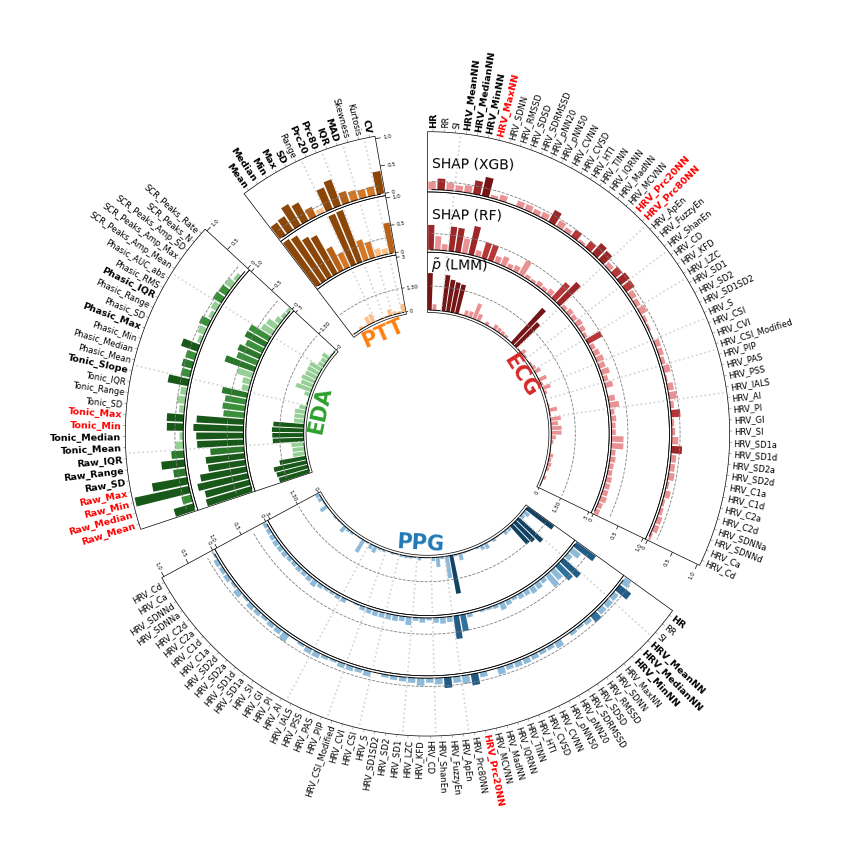

[Visualization] Flexible circos saved to <REPO_ROOT>/runs/08_final_report_v2/results/circos_shap_allmodels_lmm_highlighted_30.png
[Saved] summary      : <REPO_ROOT>/runs/08_final_report_v2/results/circos_shap_allmodels_lmm_highlighted_30_feature_condition_summary.csv
[Saved] all 3 met    : <REPO_ROOT>/runs/08_final_report_v2/results/circos_shap_allmodels_lmm_highlighted_30_features_all_3_met.csv
[Saved] >=2 met      : <REPO_ROOT>/runs/08_final_report_v2/results/circos_shap_allmodels_lmm_highlighted_30_features_at_least_2_met.csv
         feature modality  mean_abs_shap_xgb  scaled_xgb
112  EDA_Raw_Min      EDA           0.213145         1.0

[PTT]
0 SHAP (XGB) t_inner= 89.667 t_outer= 112.0 width= 22.333
1 SHAP (RF) t_inner= 67.333 t_outer= 89.667 width= 22.333
2 $\tilde{p}$ (LMM) t_inner= 45.0 t_outer= 67.333 width= 22.333


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from pycirclize import Circos
import warnings
from IPython.display import display
from pycirclize import config
config.R_PLOT_MARGIN = 0


warnings.simplefilter(action='ignore', category=FutureWarning)


def darken_color(color, factor=0.8):
    rgb = np.array(to_rgb(color))
    return tuple(np.clip(rgb * factor, 0, 1))


def plot_flexible_circos(
    res_df,
    save_path,
    track_configs,
    shap_df=None,
    equal_sector_width=False,
    title="Flexible Circos Profile",
    center_text=None,
    p_sig_col="p_max_used",
    p_sig_threshold=0.05,
    candidate_threshold=20,
):
    """
    track_configs example:
    [
        {"col": "mean_abs_shap_xgb", "kind": "shap", "label": "SHAP (XGB)", "transform": "none"},
        {"col": "mean_abs_shap_rf",  "kind": "shap", "label": "SHAP (RF)",  "transform": "none"},
        {"col": "mean_abs_shap_lr",  "kind": "shap", "label": "SHAP (LR)",  "transform": "none"},
        {"col": "p_max_used",        "kind": "p",    "label": "p_max",      "transform": "none"},
    ]
    """

    order_map, group_map = build_feature_order_and_group()

    df = res_df.copy()
    df["modality"] = pd.Categorical(
        df["feature"].astype(str).str.split("_").str[0],
        categories=["ECG", "PPG", "EDA", "PTT"],
        ordered=True
    )

    df = df[df["modality"].notna()].reset_index(drop=True)

    # merge shap if provided
    if shap_df is not None:
        shap_df = shap_df.copy()
        shap_df["mean_abs_shap"] = pd.to_numeric(shap_df["mean_abs_shap"], errors="coerce")
        df = df.merge(shap_df[["feature", "mean_abs_shap"]], on="feature", how="left")

    # ordering / labels
    df["plot_order"] = df["feature"].map(order_map).fillna(999999)
    df["group_name"] = df["feature"].map(group_map).fillna("Other")
    df["label_short"] = df["feature"].apply(shorten_feature_label)
    df = df.sort_values(by=["modality", "plot_order", "feature"]).reset_index(drop=True)

    mod_colors = {
        "ECG": "#d62728",
        "PPG": "#1f77b4",
        "EDA": "#2ca02c",
        "PTT": "#ff7f0e",
    }

    group_sizes = df.groupby("modality", observed=False).size().to_dict()
    sectors = {k: v for k, v in group_sizes.items() if v > 0}

    if equal_sector_width:
        max_n = max(sectors.values())
        sectors = {k: max_n for k in sectors.keys()}

    circos = Circos(sectors, space=10)

    # ---------- preprocess track values ----------
    processed = []
    feature_summary_rows = []
    for cfg in track_configs:
        col = cfg["col"]
        kind = cfg.get("kind", "z")
        transform = cfg.get("transform", None)
        label = cfg.get("label", col)

        vals = pd.to_numeric(df[col], errors="coerce").fillna(0.0).to_numpy()

        if kind == "z":
            plot_vals = vals.copy()
            threshold = cfg.get("threshold", 1.96)
            vmax = cfg.get("vmax", max(4.0, float(np.ceil(np.nanmax(np.abs(plot_vals)) * 2) / 2)))
            vmin = -vmax
            tick_vals = [vmin, -threshold, threshold, vmax]
            tick_labels = [f"{vmin:g}", f"{-threshold:g}", f"{threshold:g}", f"{vmax:g}"]
            q_top = q70 = q80 = q90 = None
            scale_min = scale_max = None

        elif kind == "p":
            if transform is None:
                transform = "neglog10"

            vals = np.clip(vals, 1e-300, 1.0)

            if transform == "neglog10":
                plot_vals = -np.log10(vals)
                alpha = cfg.get("alpha", 0.05)
                threshold = -np.log10(alpha)
                vmax = cfg.get("vmax", max(2.0, float(np.ceil(np.nanmax(plot_vals) * 2) / 2)))
                vmin = 0.0
                tick_vals = [0.0, threshold, vmax]
                tick_labels = ["0", f"{threshold:.2f}", f"{vmax:g}"]
            else:
                plot_vals = vals.copy()
                alpha = cfg.get("alpha", 0.05)
                threshold = alpha
                vmax = cfg.get("vmax", 1.0)
                vmin = 0.0
                tick_vals = [0.0, alpha, vmax]
                tick_labels = ["0", f"{alpha:g}", f"{vmax:g}"]

            q_top = q70 = q80 = q90 = None
            scale_min = scale_max = None

        elif kind == "shap":
            vals = np.clip(vals, 0.0, None)

            if transform == "sqrt":
                vals_t = np.sqrt(vals)
            elif transform == "log1p":
                vals_t = np.log1p(vals)
            elif transform == "rank":
                vals_t = pd.Series(vals).rank(pct=True, method="average").to_numpy()
            else:
                vals_t = vals.copy()

            scale_min = float(np.nanmin(vals_t)) if np.isfinite(np.nanmin(vals_t)) else 0.0
            scale_max = float(np.nanmax(vals_t)) if np.isfinite(np.nanmax(vals_t)) else 1.0
            print(f"[preprocess] {col}: scale_min={scale_min:.6f}, scale_max={scale_max:.6f}")

            if scale_max > scale_min:
                plot_vals = (vals_t - scale_min) / (scale_max - scale_min)
            else:
                plot_vals = np.zeros_like(vals_t, dtype=float)

            print(f"[{col}] scaled min={plot_vals.min():.6f}, scaled max={plot_vals.max():.6f}")
            print("argmax feature:", df.loc[np.nanargmax(plot_vals), "feature"])

            vmin = 0.0
            vmax = 1.0
            tick_vals = [0.0, 0.5, 1.0]
            tick_labels = ["0", "0.5", "1.0"]
            threshold = None

            if candidate_threshold > 1:
                top_percentile = (152 - candidate_threshold) / 152 * 100
                q_top = np.nanpercentile(plot_vals, top_percentile)
            else:
                q_top = None

            q70 = np.nanpercentile(plot_vals, 70)
            q80 = np.nanpercentile(plot_vals, 80)
            q90 = np.nanpercentile(plot_vals, 90)

        else:
            raise ValueError(f"Unsupported kind: {kind}")

        processed.append({
            "col": col,
            "kind": kind,
            "label": label,
            "values": plot_vals,
            "vmin": vmin,
            "vmax": vmax,
            "tick_vals": tick_vals,
            "tick_labels": tick_labels,
            "threshold": threshold,
            "transform": transform,
            "q70": q70,
            "q80": q80,
            "q90": q90,
            "q_top": q_top if candidate_threshold > 1 else 0,
            "scale_min": scale_min,
            "scale_max": scale_max,
        })

    # ---------- layout ----------
    n_tracks = len(processed)
    outer_r, inner_r = 112, 45
    track_width = (outer_r - inner_r) / n_tracks

    for s_idx, sector in enumerate(circos.sectors):
        mod = sector.name
        mod_df = df[df["modality"] == mod].reset_index(drop=True)
        n_feat = len(mod_df)
        if n_feat == 0:
            continue

        sector.text(mod, size=15, r=inner_r - 8, color=mod_colors[mod], weight="bold")

        x = np.linspace(sector.start + 0.5, sector.end - 0.5, n_feat)
        labels = mod_df["label_short"].astype(str).tolist()
        group_names = mod_df["group_name"].tolist()

        # ---------------------------------------------------
        # label condition masks
        # red   : 모든 조건 만족
        # bold  : 2개 이상 만족
        # ---------------------------------------------------
        pvals_for_label = pd.to_numeric(mod_df[p_sig_col], errors="coerce").fillna(1.0).to_numpy()
        p_sig_mask = pvals_for_label <= p_sig_threshold

        shap_sig_masks = []
        for meta in processed:
            if meta["kind"] == "shap":
                raw_vals = pd.to_numeric(mod_df[meta["col"]], errors="coerce").fillna(0.0).to_numpy()
                raw_vals = np.clip(raw_vals, 0.0, None)

                if meta["transform"] == "sqrt":
                    shap_tmp = np.sqrt(raw_vals)
                elif meta["transform"] == "log1p":
                    shap_tmp = np.log1p(raw_vals)
                elif meta["transform"] == "rank":
                    shap_tmp = pd.Series(raw_vals).rank(pct=True, method="average").to_numpy()
                else:
                    shap_tmp = raw_vals.copy()

                if meta["scale_max"] is not None and meta["scale_max"] > meta["scale_min"]:
                    shap_scaled = (shap_tmp - meta["scale_min"]) / (meta["scale_max"] - meta["scale_min"])
                else:
                    shap_scaled = np.zeros_like(shap_tmp, dtype=float)

                if candidate_threshold == 0.3:
                    shap_sig_masks.append(shap_scaled >= meta["q70"])
                elif candidate_threshold == 0.2:
                    shap_sig_masks.append(shap_scaled >= meta["q80"])
                elif candidate_threshold == 0.1:
                    shap_sig_masks.append(shap_scaled >= meta["q90"])
                elif candidate_threshold > 1:
                    shap_sig_masks.append(shap_scaled >= meta["q_top"])

        cond_list = [p_sig_mask] + shap_sig_masks

        if len(cond_list) > 0:
            cond_sum = np.sum(np.vstack(cond_list), axis=0)
            bold_required = min(2, len(cond_list))
            label_bold = cond_sum >= bold_required
            label_red = cond_sum == len(cond_list)
        else:
            label_bold = np.zeros(len(mod_df), dtype=bool)
            label_red = np.zeros(len(mod_df), dtype=bool)

        # ---------------------------------------------------
        # save summary rows for this modality
        # ---------------------------------------------------
        summary_df = mod_df[["feature", "label_short", "modality"]].copy()
        summary_df["p_sig"] = p_sig_mask.astype(int)

        for j, shap_mask in enumerate(shap_sig_masks, start=1):
            summary_df[f"shap_sig_{j}"] = shap_mask.astype(int)

        summary_df["n_conditions_met"] = cond_sum if len(cond_list) > 0 else 0
        summary_df["all_3_met"] = label_red.astype(int)          # 3개 다 만족
        summary_df["at_least_2_met"] = label_bold.astype(int)   # 2개 이상 만족

        feature_summary_rows.append(summary_df)

        for idx, meta in enumerate(processed):
            t_outer = outer_r - (idx * track_width)
            t_inner = t_outer - track_width
            track = sector.add_track((t_inner, t_outer), r_pad_ratio=0.08)
            track.axis()

            y_vals = pd.to_numeric(mod_df[meta["col"]], errors="coerce").fillna(0.0).to_numpy(dtype=float)

            # apply transform
            if meta["kind"] == "z":
                y_plot = y_vals

            elif meta["kind"] == "p":
                y_vals = np.clip(y_vals, 1e-300, 1.0)
                if meta["transform"] == "neglog10":
                    y_plot = -np.log10(y_vals)
                else:
                    y_plot = y_vals

            elif meta["kind"] == "shap":
                y_vals = np.clip(y_vals, 0.0, None)

                if meta["transform"] == "sqrt":
                    y_vals_t = np.sqrt(y_vals)
                elif meta["transform"] == "log1p":
                    y_vals_t = np.log1p(y_vals)
                elif meta["transform"] == "rank":
                    y_vals_t = pd.Series(y_vals).rank(pct=True, method="average").to_numpy()
                else:
                    y_vals_t = y_vals

                if meta["scale_max"] is not None and meta["scale_max"] > meta["scale_min"]:
                    y_plot = (y_vals_t - meta["scale_min"]) / (meta["scale_max"] - meta["scale_min"])
                else:
                    y_plot = np.zeros_like(y_vals_t, dtype=float)
                    print("fail")

            else:
                y_plot = y_vals

            # bar 강조 스타일
            for xi, yi, raw_y, feat_red in zip(x, y_plot, y_vals, label_red):
                base_color = mod_colors[mod]
                face_color = base_color
                alpha = 0.45
                ec = "none"
                lw = 0.0

                if meta["kind"] == "p":
                    is_sig = raw_y <= p_sig_threshold
                    if is_sig:
                        face_color = darken_color(base_color, 0.55)
                        alpha = 1.0
                        ec = "black"
                    else:
                        face_color = base_color
                        alpha = 0.50

                elif meta["kind"] == "shap":
                    if yi >= meta["q90"] and (candidate_threshold == 0.1 or candidate_threshold == 0.2 or candidate_threshold == 0.3):
                        face_color = darken_color(base_color, 0.55)
                        alpha = 1.0
                        ec = "black"
                    elif yi >= meta["q80"] and (candidate_threshold == 0.2 or candidate_threshold == 0.3):
                        face_color = darken_color(base_color, 0.70)
                        alpha = 0.95
                        ec = "black"
                    elif yi >= meta["q70"] and candidate_threshold == 0.3:
                        face_color = darken_color(base_color, 0.82)
                        alpha = 0.90
                        ec = "none"
                    elif yi >= meta["q_top"] and candidate_threshold > 1:
                        face_color = darken_color(base_color, 0.55)
                        alpha = 1.0
                        ec = "black"
                    else:
                        face_color = base_color
                        alpha = 0.50

                else:
                    if feat_red:
                        face_color = darken_color(base_color, 0.75)
                        alpha = 0.95
                        ec = "black"
                    else:
                        face_color = base_color
                        alpha = 0.5

                track.bar(
                    [xi], [yi],
                    vmin=meta["vmin"], vmax=meta["vmax"],
                    color=face_color,
                    alpha=alpha,
                    ec=ec,
                    lw=lw,
                    width=0.82
                )

            # baseline / thresholds
            if meta["kind"] == "z":
                track.line(
                    x, np.zeros_like(x),
                    vmin=meta["vmin"], vmax=meta["vmax"],
                    color="black", lw=0.7
                )
                track.line(
                    x, np.full_like(x, meta["threshold"]),
                    vmin=meta["vmin"], vmax=meta["vmax"],
                    color="grey", lw=0.5, ls="--"
                )
                track.line(
                    x, np.full_like(x, -meta["threshold"]),
                    vmin=meta["vmin"], vmax=meta["vmax"],
                    color="grey", lw=0.5, ls="--"
                )

            elif meta["kind"] == "p":
                track.line(
                    x, np.zeros_like(x),
                    vmin=meta["vmin"], vmax=meta["vmax"],
                    color="black", lw=0.7
                )
                if meta["threshold"] is not None:
                    track.line(
                        x, np.full_like(x, meta["threshold"]),
                        vmin=meta["vmin"], vmax=meta["vmax"],
                        color="grey", lw=0.6, ls="--"
                    )

            elif meta["kind"] == "shap":
                track.line(
                    x, np.zeros_like(x),
                    vmin=meta["vmin"], vmax=meta["vmax"],
                    color="black", lw=0.7
                )
                temp = (
                    meta["q70"] if candidate_threshold == 0.3
                    else meta["q80"] if candidate_threshold == 0.2
                    else meta["q90"] if candidate_threshold == 0.1
                    else meta["q_top"]
                )
                for q, c, ls, lw_ in [
                    (temp, "grey", "--", 0.60),
                ]:
                    track.line(
                        x, np.full_like(x, q),
                        vmin=meta["vmin"], vmax=meta["vmax"],
                        color=c, lw=lw_, ls=ls
                    )

            # subgroup separators
            for i in range(1, len(group_names)):
                if group_names[i] != group_names[i - 1]:
                    x_sep = (x[i - 1] + x[i]) / 2.0
                    y0 = meta["vmin"]
                    y1 = meta["vmax"]
                    track.line(
                        [x_sep, x_sep], [y0, y1],
                        vmin=meta["vmin"], vmax=meta["vmax"],
                        color="lightgrey", lw=1.2, ls=":"
                    )

            # y axis ticks
            track.yticks(
                meta["tick_vals"],
                labels=meta["tick_labels"],
                vmin=meta["vmin"],
                vmax=meta["vmax"],
                label_size=4,
                tick_length=1
            )

            # outermost: feature labels
            if idx == 0:
                for x_pos, label, is_bold, is_red in zip(x, labels, label_bold, label_red):
                    track.xticks(
                        [x_pos], [label],
                        tick_length=1,
                        show_bottom_line=False,
                        label_orientation="vertical",
                        label_size=6.8 if is_bold else 6,
                        line_kws=dict(ec="grey", lw=0.4),
                        text_kws=dict(
                            weight="bold" if is_bold else "normal",
                            color="red" if is_red else "black"
                        )
                    )

            if s_idx == 0:
                
                track.text(
                    meta["label"],
                    x=sector.start + 0.5,
                    r=(t_inner + t_outer) / 2 + 3.5*idx-1,
                    size=10,
                    ha="left",
                    ignore_range_error=True
                )

    fig = circos.plotfig()
    ax = fig.axes[0]
    ax.set_rlim(0, outer_r)

    if center_text is not None:
        fig.text(0.5, 0.5, center_text, ha="center", va="center", fontsize=6)

    fig.savefig(save_path, dpi=600, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print(f"[Visualization] Flexible circos saved to {save_path}")

    # ---------------------------------------------------
    # save feature lists
    # ---------------------------------------------------
    if len(feature_summary_rows) > 0:
        feature_summary_df = pd.concat(feature_summary_rows, axis=0, ignore_index=True)
        feature_summary_df = feature_summary_df.sort_values(
            by=["modality", "n_conditions_met", "feature"],
            ascending=[True, False, True]
        ).reset_index(drop=True)

        all3_df = feature_summary_df[feature_summary_df["all_3_met"] == 1].copy()
        ge2_df = feature_summary_df[feature_summary_df["at_least_2_met"] == 1].copy()

        save_dir = Path(save_path).parent
        stem = Path(save_path).stem

        summary_csv = save_dir / f"{stem}_feature_condition_summary.csv"
        all3_csv = save_dir / f"{stem}_features_all_3_met.csv"
        ge2_csv = save_dir / f"{stem}_features_at_least_2_met.csv"

        feature_summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")
        all3_df.to_csv(all3_csv, index=False, encoding="utf-8-sig")
        ge2_df.to_csv(ge2_csv, index=False, encoding="utf-8-sig")

        print(f"[Saved] summary      : {summary_csv}")
        print(f"[Saved] all 3 met    : {all3_csv}")
        print(f"[Saved] >=2 met      : {ge2_csv}")

    tmp = df[["feature", "modality", "mean_abs_shap_xgb"]].copy()
    vals = pd.to_numeric(tmp["mean_abs_shap_xgb"], errors="coerce").fillna(0.0).to_numpy()
    scale_min = float(np.nanmin(vals))
    scale_max = float(np.nanmax(vals))
    scaled = (vals - scale_min) / (scale_max - scale_min)
    tmp["scaled_xgb"] = scaled
    print(tmp.loc[tmp["feature"] == "EDA_Raw_Min"])

    print(f"\n[{mod}]")
    for idx, meta in enumerate(processed):
        t_outer = outer_r - (idx * track_width)
        t_inner = t_outer - track_width
        print(
            idx, meta["label"],
            "t_inner=", round(t_inner, 3),
            "t_outer=", round(t_outer, 3),
            "width=", round(t_outer - t_inner, 3)
        )

plot_flexible_circos(
    res_df=res_df,
    save_path=EXPORT_ROOT / "circos_shap_allmodels_lmm_highlighted_30.png",
    track_configs=[
        {"col": "mean_abs_shap_xgb", "kind": "shap", "label": "SHAP (XGB)", "transform": "none"},
        {"col": "mean_abs_shap_rf",  "kind": "shap", "label": "SHAP (RF)",  "transform": "none"},
        {"col": "p_max_used",        "kind": "p",    "label": r"$\tilde{p}$ (LMM)"},
    ],
    center_text=(
        # "Inner track: $-\\log_{10}(p_{max})$.\n\n"
        # "Outer tracks: rescaled SHAP values\n(0-1, model-wise min-max scaling).\n\n"
        # "Red bold labels:features satisfying\n all criteria simultaneously.\n\n"
        # "Bars are darker for more salient features."
        " "
    ),
    p_sig_col="p_max_used",
    p_sig_threshold=0.05,
    candidate_threshold = 0.3,
)


## Table VII: 3-class recognition using the 36 candidate physiomarker features

Re-runs the 3-class sweep restricted to the 36 features selected by the combined LMM + dual-model SHAP screen above (`..._feature_condition_summary.csv`, `at_least_2_met`/`all_3_met` columns). Kept as its own sweep (writing to a distinct `ALL_36feat` results folder) so it cannot silently overwrite the full-feature Table III-VI results computed earlier in this notebook.

In [10]:
selected_feature_csv = str(EXPORT_ROOT / "circos_shap_allmodels_lmm_highlighted_30_features_at_least_2_met.csv")
table7_results = []

if not Path(selected_feature_csv).exists():
    print(f"Skipping Table VII: {selected_feature_csv} not found. "
          f"Run the 'Combined Circos Plot' cells above first, then re-run this cell.")
else:
    db36, af36 = load_and_label('10s', REPO_ROOT, Q_CSV, n_classes=3, filter_abnormal=True, prefix="_05_70_3",
                                 compare='z_vs_lh', selected_feature_csv=selected_feature_csv)
    if db36 is not None:
        seed_everything(SEED)
        paths36 = get_save_paths(3, 'ALL_36feat')
        cur_curves = {}
        for m_name in ['KNN', 'SVM', 'LR', 'MLP', 'XGB', 'RF']:
            try:
                m_res, yt, pb = run_full_experiment(db36, af36, m_name, paths36, "3class", "ALL_36feat")
                m_res.update({'n_classes': 3, 'duration': '10s', 'modality': 'ALL_36feat',
                              'model': m_name, 'samples': len(db36)})
                table7_results.append(m_res)
                cur_curves[m_name] = (yt, pb)
            except Exception as e:
                print(f"  [Error {m_name}] {e}")
        if cur_curves:
            save_compare_figure(cur_curves, np.unique(db36['y']), paths36['plots'],
                                 "Models Comparisons | 3c | 10s | ALL_36feat")
        pd.DataFrame(table7_results).to_csv(EXPORT_ROOT / 'results_metrics_36feat.csv', index=False)
        print("\n✅ Table VII (36 candidate features) complete.")


  [Filter] NULL applied to abnormal sessions (no row drop)
Skipping EDA_SCR_IPI_Mean: NaN ratio 50.25%
Skipping EDA_SCR_IPI_SD: NaN ratio 50.25%
Skipping ECG_HRV_DFA_alpha1: NaN ratio 54.49%
Skipping ECG_HRV_HFD: NaN ratio 99.34%
Skipping ECG_HRV_MFDFA_alpha1_Asymmetry: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Delta: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Fluctuation: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Increment: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Max: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Mean: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Peak: NaN ratio 54.49%
Skipping ECG_HRV_MFDFA_alpha1_Width: NaN ratio 54.49%
Skipping ECG_HRV_SampEn: NaN ratio 87.55%
Skipping ECG_HRV_Symbolic_EqualProb4_0V: Symbolic_EqualProb
Skipping ECG_HRV_Symbolic_EqualProb4_1V: Symbolic_EqualProb
Skipping ECG_HRV_Symbolic_EqualProb4_2LV: Symbolic_EqualProb
Skipping ECG_HRV_Symbolic_EqualProb4_2UV: Symbolic_EqualProb
Skipping ECG_HRV_TP: Constant value
Skipping


✅ Table VII (36 candidate features) complete.
